### Cumulative Transport Sum Notebook

Calculate the yearly cumulative sum of transport entering SoG

In [1]:
import arrow
import datetime as dt
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

In [2]:
section = 2
thedir = '/data/sallen/results/Ariane/v202111/FullSouth/'
years = [2015, 2016, 2017, 2018, 2019, 2020]

In [3]:
sal_cut = 30.5
depth_cut = -0

Patch bad dates

In [4]:
bad_dates = [dt.datetime(2015, 1, 31), dt.datetime(2019, 4, 30), dt.datetime(2020, 8, 6)]
trans_for_bad = {}
for r in bad_dates:
    before = arrow.get(r).shift(days=-1)
    filename = (thedir+before.format('DDMMMYY').lower()+'/ariane_positions_quantitative.nc')
    before_data = xr.open_dataset(filename)
    before_deep_transports = np.sum(before_data.final_transp[(before_data.final_section==section) &
                                                    (before_data.final_depth <= depth_cut) &
                                            (before_data.final_salt > sal_cut)])/24.

    after = arrow.get(r).shift(days=+1)
    filename = (thedir+after.format('DDMMMYY').lower()+'/ariane_positions_quantitative.nc')
    after_data = xr.open_dataset(filename)
    after_deep_transports = np.sum(after_data.final_transp[(after_data.final_section==section) &
                                                    (after_data.final_depth <= depth_cut) &
                                            (after_data.final_salt > sal_cut)])/24.
    trans_for_bad[arrow.get(r)] = 0.5*(before_deep_transports + after_deep_transports)

In [5]:
deep_transports = np.zeros((6, 365))
for jj, year in enumerate(years):
    print (year)
    start = dt.datetime(year, 1, 1)
    endtime = dt.datetime(year, 12, 31)
    timerange = [d for d in arrow.Arrow.range('day', start, endtime)
                    if not (d.month == 2 and d.day == 29)]

    for ii, r in enumerate(timerange):
        if r in trans_for_bad.keys():
            print ('here', r)
            deep_transports[jj, ii] = trans_for_bad[r]
        else:
            filename = (thedir+r.format('DDMMMYY').lower()+'/ariane_positions_quantitative.nc')
            mydata = xr.open_dataset(filename)
            deep_transports[jj, ii] = np.sum(mydata.final_transp[(mydata.final_section==section) &
                                                    (mydata.final_depth <= depth_cut) &
                                            (mydata.final_salt > sal_cut)])/24.

2015
here 2015-01-31T00:00:00+00:00
2016
2017
2018
2019
here 2019-04-30T00:00:00+00:00
2020
here 2020-08-06T00:00:00+00:00


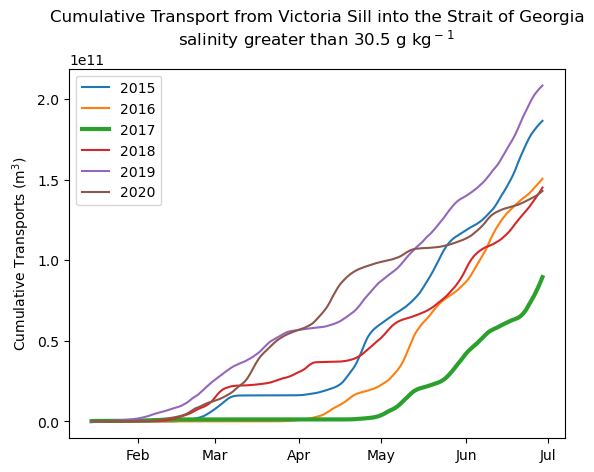

In [6]:
start_day, end_day = 15, 181 #15, 181+21
day_of_year = np.arange(start_day, end_day)
dates = pd.to_datetime('2015-01-01') + pd.to_timedelta(day_of_year - 1, unit='D')

fig, ax = plt.subplots(1, 1)
ax.plot(dates, np.cumsum(deep_transports[0, start_day:end_day]*86400), label='2015')
ax.plot(dates, np.cumsum(deep_transports[1, start_day:end_day]*86400), label='2016')
ax.plot(dates, np.cumsum(deep_transports[2, start_day:end_day]*86400), label='2017', linewidth=3)
ax.plot(dates, np.cumsum(deep_transports[3, start_day:end_day]*86400), label='2018')
ax.plot(dates, np.cumsum(deep_transports[4, start_day:end_day]*86400), label='2019')
ax.plot(dates, np.cumsum(deep_transports[5, start_day:end_day]*86400), label='2020')
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.legend();
ax.set_ylabel('Cumulative Transports (m$^3$)');
ax.set_title(f'Cumulative Transport from Victoria Sill into the Strait of Georgia\n'+
            f'salinity greater than {sal_cut} g kg$^-$$^1$');
fig.savefig('/ocean/atall/MOAD/analysis-abdoul/figures/figsAnalysiSOG/CumulTransVicSillToSoG.png',dpi=300)
fig.savefig('/ocean/atall/MOAD/analysis-abdoul/figures/figsAnalysiSOG/CumulTransVicSillToSoG.pdf',dpi=300)


cum_transport = np.cumsum(deep_transports[:, start_day:end_day] * 86400,axis=1)

ds = xr.Dataset(
    data_vars={
        "daily_transport": (("year", "time"),deep_transports[:, start_day:end_day]),
        "cumulative_transport": (("year", "time"),cum_transport),
    },
    coords={
        "year": [2015, 2016, 2017, 2018, 2019, 2020],
        "time": dates,
    },
    attrs={
        "title": "Processed data used to generate Figure 11",
        "description": ("Daily and cumulative deep transport across Victoria Sill "
            f"for water with salinity > {sal_cut} g kg-1."
        ),
        "units_daily_transport": "m3 s-1",
        "units_cumulative_transport": "m3",
        "salinity_threshold": sal_cut,
        "model": "SalishSeaCast 202111",
    }
)
ds.to_netcdf("/ocean/atall/MOAD/Talletal_OxygenSoGpaper/data/Fig11_CumulativeTransport.nc")

In [7]:
start_day, end_day = 15, 181

# Total transport over the plotted period (m3)
cumulative_transport = np.sum(
    deep_transports[:, start_day:end_day] * 86400,
    axis=1
)

years = np.arange(2015, 2021)

for year, transport in zip(years, cumulative_transport):
    print(f"{year}: {transport:.3e} m3")

2015: 1.864e+11 m3
2016: 1.504e+11 m3
2017: 8.946e+10 m3
2018: 1.450e+11 m3
2019: 2.083e+11 m3
2020: 1.428e+11 m3


In [8]:
mean_transport = cumulative_transport.mean()

transport_2017 = cumulative_transport[2]

reduction_2017 = (
    1 - transport_2017 / mean_transport
) * 100

print(f"Mean 2015–2020: {mean_transport:.3e} m3")
print(f"2017:            {transport_2017:.3e} m3")
print(f"2017 reduction:  {reduction_2017:.1f}%")

Mean 2015–2020: 1.537e+11 m3
2017:            8.946e+10 m3
2017 reduction:  41.8%
